# IESO Data Preprocessing

In [67]:
import pandas as pd
import numpy as np
#os is used for MacOS paths
import os
#The glob module is used to find all file names matching a pattern,
from glob import glob
from zoneinfo import ZoneInfo #vectorized version of pytz - much faster

# Set the folder containing your monthly CSV files
folder_path = '/Users/will/Documents/Beacon MVP/Projects/IESO Data Set Up/IESO Historic Data'
output_folder = '/Users/will/Documents/Beacon MVP/Projects/IESO Data Set Up/output_data/'


# Get list of all CSV files in the folder
csv_files = glob(os.path.join(folder_path, '*.csv'))

# Read each CSV while skipping the first 3 rows, then concatenate
#df_all = pd.concat(
#    (pd.read_csv(file, skiprows=3) for file in csv_files),
#    ignore_index=True
#)

dfs = []

for file in csv_files:
    try:
        # Use 7 for this specific file, 3 for all others
        if os.path.basename(file) == 'PUB_HourlyConsumptionByFSA_202308_v1.csv':
            df = pd.read_csv(file, skiprows=7)
        else:
            df = pd.read_csv(file, skiprows=3)

        dfs.append(df)
    except Exception as e:
        print(f"Error reading {file}: {e}")

# Concatenate all dataframes
df_all = pd.concat(dfs, ignore_index=True)

In [69]:
df_all.tail()

,FSA,DATE,HOUR,CUSTOMER_TYPE,PRICE_PLAN,TOTAL_CONSUMPTION,PREMISE_COUNT
32902626,K7P,2024-12-31,24,SGS <50kW,TOU,1254.8,485
32902627,M6S,2024-12-31,24,Residential,ULO,124.6,105
32902628,P4N,2024-12-31,24,Residential,Retailer,175.5,152
32902629,N2R,2024-12-31,24,Residential,Tiered,623.7,831
32902630,L0P,2024-12-31,24,Residential,TOU,6833.4,2785


In [51]:
## Find unique values
num_fsa = len(df_all['FSA'].unique())
customer_types = df_all['CUSTOMER_TYPE'].unique()
price_plans = df_all['PRICE_PLAN'].unique()

print(f'number of fsas: {num_fsa}') 
print(f'customer types: {customer_types}') 
print(f'price plans: {price_plans}') 

number of fsas: 563
customer types: ['Residential' 'SGS <50kW']
price plans: ['Tiered' 'TOU' 'Retailer' 'ULO']


In [52]:
# Automated exploratory analysis
#from ydata_profiling import ProfileReport
#import pandas as pd

#profile = ProfileReport(df_all, title="Training Data Profile", explorative=True)
#profile.to_file("training_data_report.html")  # or .to_notebook_iframe()


In [53]:
df_all.head()

,FSA,DATE,HOUR,CUSTOMER_TYPE,PRICE_PLAN,TOTAL_CONSUMPTION,PREMISE_COUNT
0,M4S,2023-01-01,1,Residential,Tiered,351.7,732
1,K7K,2023-01-01,1,Residential,Tiered,519.4,821
2,P4N,2023-01-01,1,SGS <50kW,TOU,2106.6,796
3,N3E,2023-01-01,1,Residential,Tiered,41.2,63
4,M4S,2023-01-01,1,SGS <50kW,Tiered,478.7,170


# Generating ISO datetime column

In [71]:
from zoneinfo import ZoneInfo
import pandas as pd

# create datetime column
df_all['datetime'] = pd.to_datetime(df_all['DATE']) + pd.to_timedelta(df_all['HOUR'] - 1, unit='h')

# IESO data is in LST so Convert LST (UTC-5) to UTC
df_all['datetime_utc'] = df_all['datetime'] + pd.Timedelta(hours=5)

# Convert UTC to local time with DST awareness
df_all['datetime_et'] = df_all['datetime_utc'].dt.tz_localize('UTC').dt.tz_convert(ZoneInfo('America/Toronto'))


In [66]:
# Step 1: Load time in UTC and convert to America/Toronto (Eastern Time)
#df_all['datetime'] = pd.to_datetime(df_all['DATE']) + pd.to_timedelta(df_all['HOUR'] - 1, unit='h')

#df_all['datetime_et'] = df_all['datetime'].dt.tz_localize('UTC').dt.tz_convert(ZoneInfo('America/Toronto'))


In [64]:
#old code
'''
# Convert to datetime, subtract 1 from hour to align with 0-23
df_all['datetime'] = pd.to_datetime(df_all['DATE']) + pd.to_timedelta(df_all['HOUR'] - 1, unit='h')

# Localize to Eastern Time with proper handling of DST transitions
TO_eastern = pytz.timezone("America/Toronto")

# Option 1: Shift forward (2:00 AM becomes 3:00 AM)
df_all['datetime_et'] = df_all['datetime'].dt.tz_localize('America/Toronto', nonexistent='shift_forward',ambiguous='infer')

# Convert to ISO format string
df_all['datetime_iso'] = df_all['datetime_et'].apply(lambda x: x.isoformat())
'''

'\n# Convert to datetime, subtract 1 from hour to align with 0-23\ndf_all[\'datetime\'] = pd.to_datetime(df_all[\'DATE\']) + pd.to_timedelta(df_all[\'HOUR\'] - 1, unit=\'h\')\n\n# Localize to Eastern Time with proper handling of DST transitions\nTO_eastern = pytz.timezone("America/Toronto")\n\n# Option 1: Shift forward (2:00 AM becomes 3:00 AM)\ndf_all[\'datetime_et\'] = df_all[\'datetime\'].dt.tz_localize(\'America/Toronto\', nonexistent=\'shift_forward\',ambiguous=\'infer\')\n\n# Convert to ISO format string\ndf_all[\'datetime_iso\'] = df_all[\'datetime_et\'].apply(lambda x: x.isoformat())\n'

In [73]:
#using datetime_et as it is datetime type 
# datetime_iso is str
df_grouped = df_all.groupby(['datetime_et', 'FSA'], as_index=False)['TOTAL_CONSUMPTION'].sum()

In [75]:
df_test = df_grouped[(df_grouped['datetime_et'].dt.year == 2024) & (df_grouped['datetime_et'].dt.month == 2)]
#df_all[df_all['FSA']=='K0A']
#df_all[(df_all['FSA']=='K0A') & (df_all['HOUR']==1)]
df_test[(df_test['FSA']=='K0A')]

,datetime_et,FSA,TOTAL_CONSUMPTION
5313427,2024-02-01 00:00:00-05:00,K0A,62909.2
5313986,2024-02-01 01:00:00-05:00,K0A,60789.2
5314545,2024-02-01 02:00:00-05:00,K0A,59525.3
5315104,2024-02-01 03:00:00-05:00,K0A,59699.4
5315663,2024-02-01 04:00:00-05:00,K0A,61457.9
...,...,...,...
5699770,2024-02-29 19:00:00-05:00,K0A,99323.9
5700329,2024-02-29 20:00:00-05:00,K0A,96265.3
5700888,2024-02-29 21:00:00-05:00,K0A,90265.5
5701447,2024-02-29 22:00:00-05:00,K0A,82560.4


In [76]:
output_folder = '/Users/will/Documents/Beacon MVP/Projects/IESO Data Set Up/output_data/'

df_grouped.to_csv(os.path.join(output_folder + "load_data.csv"), index=False)

In [33]:
#from ydata_profiling import ProfileReport

#profile = ProfileReport(df_grouped, title="Grouped Training Data Profile", explorative=True)
#profile.to_file("grouped_training_data_report.html")  # or .to_notebook_iframe()

In [38]:
# replace elsewhere - delete when ready
'''
# TRAIN, VALIDATE, TEST SPLIT

df_grouped = df_grouped.sort_values("datetime_et")

# Define the split dates based on your 2-year range
start_date = df_grouped["datetime_et"].min()
end_date = df_grouped["datetime_et"].max()

# Define split points
train_end = start_date + pd.DateOffset(months=16)
val_end = train_end + pd.DateOffset(months=4)

# Split the data
train_df = df_grouped[df_grouped["datetime_et"] < train_end]
val_df   = df_grouped[(df_grouped["datetime_et"] >= train_end) & (df_grouped["datetime_et"] < val_end)]
test_df  = df_grouped[df_grouped["datetime_et"] >= val_end]

# Export to CSV
train_df.to_csv(os.path.join(output_folder + "train.csv"), index=False)
val_df.to_csv(os.path.join(output_folder + "validation.csv"), index=False)
test_df.to_csv(os.path.join(output_folder + "test.csv"), index=False)

print("✅ Exported train.csv, validation.csv, and test.csv")
'''

✅ Exported train.csv, validation.csv, and test.csv


# Exploratory analysis

In [26]:
entries_per_FSA = pd.DataFrame(df['FSA'].value_counts())
len(entries_per_FSA)

562

In [27]:
entries_per_FSA.head()

,count
FSA,
K0K,5208
K0A,5208
K0M,5208
K0H,5208
K0C,5208


In [24]:
entries_per_FSA[entries_per_FSA['count']!=5208]

,count
FSA,
N0B,4464
N0K,4464
M6K,4464
N0J,4464
N0M,4464
...,...
P0T,744
P0R,744
P7,426


,datetime_et,FSA,TOTAL_CONSUMPTION
571270,2024-01-01 00:00:00-05:00,M1T,7118.3
571829,2024-01-02 00:00:00-05:00,M1T,7176.2
572389,2024-01-03 00:00:00-05:00,M1T,7238.1
572949,2024-01-04 00:00:00-05:00,M1T,7048.7
573509,2024-01-05 00:00:00-05:00,M1T,7524.7
574069,2024-01-06 00:00:00-05:00,M1T,7317.6
574629,2024-01-07 00:00:00-05:00,M1T,7566.2
575189,2024-01-08 00:00:00-05:00,M1T,7320.2
575749,2024-01-09 00:00:00-05:00,M1T,6775.0
576310,2024-01-10 00:00:00-05:00,M1T,6806.6


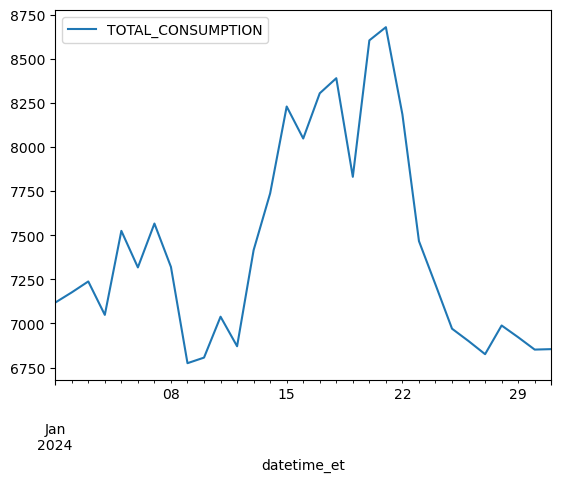

In [14]:
filtered_df = df_grouped[(df_grouped['datetime_et'].dt.year == 2024) & (df_grouped['datetime_et'].dt.month == 1)]
filtered_df[filtered_df['FSA']=='M1T'].plot(x='datetime_et', y='TOTAL_CONSUMPTION', kind='line')
filtered_df[filtered_df['FSA']=='M1T'].head(26)

In [42]:
#df = pd.read_csv('/Users/will/Downloads/PUB_HourlyConsumptionByFSA_202401_v1.csv',skiprows=3)
#'/Users/will/Documents/Beacon MVP/IESO Historic Data/PUB_HourlyConsumptionByFSA_202401_v1.csv'
df = pd.read_csv('/Users/will/Documents/Beacon MVP/IESO Historic Data/PUB_HourlyConsumptionByFSA_202401_v1.csv',skiprows=3)


In [43]:
df[df['FSA']=='K7P'].head(24)

,FSA,DATE,HOUR,CUSTOMER_TYPE,PRICE_PLAN,TOTAL_CONSUMPTION,PREMISE_COUNT
213,K7P,2024-01-01,1,Residential,TOU,6611.2,7107
908,K7P,2024-01-01,1,Residential,Tiered,1038.8,1363
1041,K7P,2024-01-01,1,Residential,Retailer,185.2,209
1367,K7P,2024-01-01,1,SGS <50kW,TOU,1313.6,482
2332,K7P,2024-01-01,2,SGS <50kW,TOU,1305.0,482
2576,K7P,2024-01-01,2,Residential,TOU,6146.2,7107
3055,K7P,2024-01-01,2,Residential,Tiered,963.2,1363
3389,K7P,2024-01-01,2,Residential,Retailer,171.9,209
4788,K7P,2024-01-01,3,Residential,Tiered,893.1,1363
5033,K7P,2024-01-01,3,Residential,TOU,5649.3,7107


In [44]:
filtered_df = df[(df['datetime_et'].dt.year == 2024) & (df['datetime_et'].dt.month == 1)]
filtered_df[filtered_df['FSA']=='M1T'].plot(x='datetime_et', y='TOTAL_CONSUMPTION', kind='line')
filtered_df[filtered_df['FSA']=='M1T'].head(26)

KeyError: 'datetime_et'